# Mesure et évolution de la volatilité d'un indice financier : cas du S&P 500

# Analyse de la volatilité d'un indice financier

## Introduction

Ce projet porte sur l'évolution de la volatilité d'un indice financier à partir de ses prix historiques.

L'objectif est de calculer les rendements journaliers, de mesurer la volatilité sur différents fénêtres et d'identifier les périodes calmes et agitées.

Les données sont analysées avec les outils Python,pandas,et matplotlib.



!pip install yfinance

In [1]:
import yfinance as yf
print ("C'est bien là!")

C'est bien là!


In [2]:
# import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf


In [3]:
# choix de actif et téléchargement des données
ticker = "^GSPC"  # S§P 500
data = yf.download(ticker,period= "2y", interval= "1d")

[*********************100%***********************]  1 of 1 completed


## Exploration des données
Nous commençons par observer la structure du tableau téléchargé.

In [4]:
print(data.head())

Price             Close         High          Low         Open      Volume
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC
Date                                                                      
2024-09-18  5618.259766  5689.750000  5615.080078  5641.680176  3691390000
2024-09-19  5713.640137  5733.569824  5686.419922  5702.629883  4024530000
2024-09-20  5702.549805  5715.140137  5674.490234  5709.640137  7867260000
2024-09-23  5718.569824  5725.359863  5704.220215  5711.899902  3529550000
2024-09-24  5732.930176  5735.319824  5698.990234  5727.660156  3872710000


In [5]:
print(data.head(10))

Price             Close         High          Low         Open      Volume
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC
Date                                                                      
2024-09-18  5618.259766  5689.750000  5615.080078  5641.680176  3691390000
2024-09-19  5713.640137  5733.569824  5686.419922  5702.629883  4024530000
2024-09-20  5702.549805  5715.140137  5674.490234  5709.640137  7867260000
2024-09-23  5718.569824  5725.359863  5704.220215  5711.899902  3529550000
2024-09-24  5732.930176  5735.319824  5698.990234  5727.660156  3872710000
2024-09-25  5722.259766  5741.029785  5712.060059  5733.649902  3624910000
2024-09-26  5745.370117  5767.370117  5721.009766  5762.220215  4391180000
2024-09-27  5738.169922  5763.779785  5727.339844  5755.359863  3898530000
2024-09-30  5762.479980  5765.140137  5703.529785  5726.520020  4425730000
2024-10-01  5708.750000  5757.729980  5681.279785  5757.729980  4025180000


In [6]:
print( "nombre de lignes:",len(data))

nombre de lignes: 501


In [7]:
print(data.shape)
print (data.columns)
print(data.index)

(501, 5)
MultiIndex([( 'Close', '^GSPC'),
            (  'High', '^GSPC'),
            (   'Low', '^GSPC'),
            (  'Open', '^GSPC'),
            ('Volume', '^GSPC')],
           names=['Price', 'Ticker'])
DatetimeIndex(['2024-09-18', '2024-09-19', '2024-09-20', '2024-09-23',
               '2024-09-24', '2024-09-25', '2024-09-26', '2024-09-27',
               '2024-09-30', '2024-10-01',
               ...
               '2026-09-03', '2026-09-04', '2026-09-08', '2026-09-09',
               '2026-09-10', '2026-09-11', '2026-09-14', '2026-09-15',
               '2026-09-16', '2026-09-17'],
              dtype='datetime64[ns]', name='Date', length=501, freq=None)


In [8]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 501 entries, 2024-09-18 to 2026-09-17
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, ^GSPC)   501 non-null    float64
 1   (High, ^GSPC)    501 non-null    float64
 2   (Low, ^GSPC)     501 non-null    float64
 3   (Open, ^GSPC)    501 non-null    float64
 4   (Volume, ^GSPC)  501 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.5 KB
None


In [9]:
close = data["Close"]
print(close.head())

Ticker            ^GSPC
Date                   
2024-09-18  5618.259766
2024-09-19  5713.640137
2024-09-20  5702.549805
2024-09-23  5718.569824
2024-09-24  5732.930176


## Évolution du prix de clôture

Ce graphique qui suivra permet d'anayser la tendance générale du prix au cours de la période étudiée.

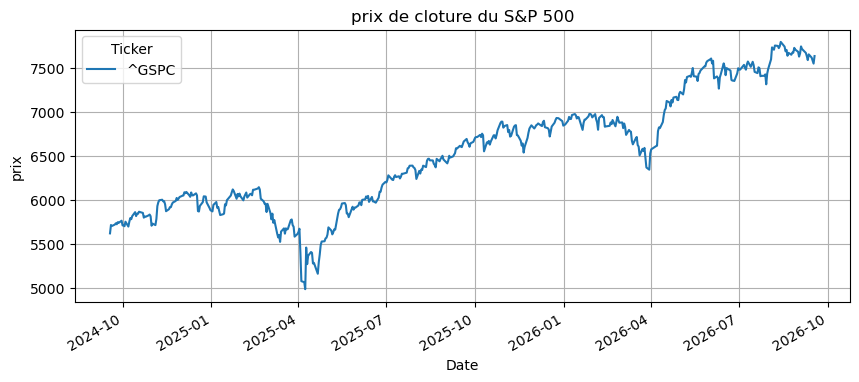

In [10]:
import matplotlib.pyplot as plt

close.plot(figsize=(10,4),title= "prix de cloture du S&P 500")
plt.xlabel("Date")
plt.ylabel("prix")
plt.grid(True)
plt.show()

Le prix évolue de manière variable au cours de la période donnée. Les fluctuations visibles ne mesurent pas directement la volatilité comme on pourrait le penser au début ; C'est pourquoi ensuite nous calculons les rendements et leur écart type.

## Méthodologie

Les prix de clôture ont été utilisés pour calculer les rendements journaliers . En effet , on s'intéresse aux paramètres qui résume la journée boursière.

Le rendment simple est calculé avec la formule ci dessus qui mesure la variation relative entre deux prix sucessifs:

R_t = (P_t - P_t-1) / P_t-1

La volatilité sur 20 jours correspond à l'écart type des rendements observées sur une fénêtre mobile de 
20 jours.
La volatilité est ensuite annualisée en la multipliant par la racine carrée  de 252  qui correspond approximativement aux jours de marché durant une année ou aux jours de cotation boursiére dans une année.

## Calcul des rendements

Nous calculons les variations journalières du prix de clôture afin de mesurer les mouvements quotidiens de l'indice.

In [11]:
# CALCUL DES RENDEMENTS SIMPLES
returns = close.pct_change()    # la methode pct_change compare chaque valeur avec la valeur precédente 
print(returns.head())

Ticker         ^GSPC
Date                
2024-09-18       NaN
2024-09-19  0.016977
2024-09-20 -0.001941
2024-09-23  0.002809
2024-09-24  0.002511


In [12]:
data["return"]= data["Close"].pct_change() # la methode pct_change compare chaque valeur avec la valeur precédente
# Là,la colonne des rendemnts journaliers a été crée .

In [13]:
print(data[["Close","return"]].head())

Price             Close    return
Ticker            ^GSPC          
Date                             
2024-09-18  5618.259766       NaN
2024-09-19  5713.640137  0.016977
2024-09-20  5702.549805 -0.001941
2024-09-23  5718.569824  0.002809
2024-09-24  5732.930176  0.002511


La première valeur est **NaN** ,car aucun rendement ne peut être calculé pour la première date : il n'existe en fait pas encore de prix précédent.

## Évolution des rendements journaliers

<function matplotlib.pyplot.show(close=None, block=None)>

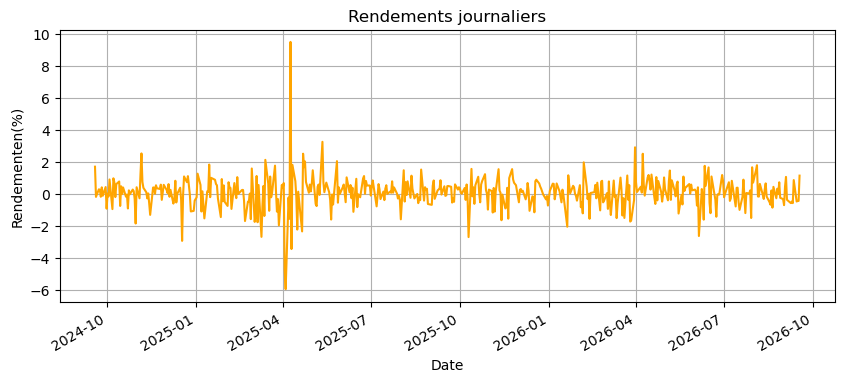

In [14]:
# tracé des rendements

(data["return"]*100).plot(figsize=(10,4),title= "Rendements journaliers",color= "orange")
plt.xlabel("Date")
plt.ylabel("Rendementen(%)")
plt.grid(True)
plt.show

### Interprétation des rendements journaliers

Le graphique montre les variations quotidiennes du prix sous forme de rendements.

Les valeurs positives correspondent aux journées où le prix a augmenté, tandis que les valeurs négatives correspondent aux journées où le prix a diminué. Les rendements sont généralement proches de zéro, mais certaines dates présentent encore des mouvements plus importants.

Les pics positifs et négatifs indiquent des journées où le marché a connu des variations plus fortes que d'habitude.Ce graphique permet peut-être d'identifier des mouvements journaliers importants, mais il ne mesure pas directement la volatlité sur une période complète.

In [15]:
print( data.shape)  
print(data.columns)    # Petite vérification pour l'ajout de la colonne des rendements
print(data[["Close","return"]].head())

(501, 6)
MultiIndex([( 'Close', '^GSPC'),
            (  'High', '^GSPC'),
            (   'Low', '^GSPC'),
            (  'Open', '^GSPC'),
            ('Volume', '^GSPC'),
            ('return',      '')],
           names=['Price', 'Ticker'])
Price             Close    return
Ticker            ^GSPC          
Date                             
2024-09-18  5618.259766       NaN
2024-09-19  5713.640137  0.016977
2024-09-20  5702.549805 -0.001941
2024-09-23  5718.569824  0.002809
2024-09-24  5732.930176  0.002511


## Volatilité glissante sur 20 jours et graphique

Nous calculons la volatilité sur une fénêtre glissante de 20 jours. Pour chaque date ,l'écart type est calculé à partir des rendements des 20 dernières séances.
Nous présentons ensuite cette volatilité sous deux formes:

*La volatilité non annualisée, qui reste exprimée sur l'échelle des rendements journaliers.

*La volatilité annualisée qui convertit notre mesure journalière en une estimation sur une base annuelle

La volatilité annualisée est obtenu en multipliant la volatilité non annualisée par la racine carré de 252, qui correspond approximativement au nombre de séances boursières dans une année.


In [16]:
data["volatility_20d"] = data["return"].rolling(window=20).std()

In [17]:
data.columns= data.columns.get_level_values(0)      # afin de faciliter la lecture de mon Dataframe et eviter les erreurs pour la mauvaise gestion du multiIndex

In [18]:
print(data[["return","volatility_20d"]].head(25)) # Afin de remarquer logiquement les valeurs Nan

Price         return  volatility_20d
Date                                
2024-09-18       NaN             NaN
2024-09-19  0.016977             NaN
2024-09-20 -0.001941             NaN
2024-09-23  0.002809             NaN
2024-09-24  0.002511             NaN
2024-09-25 -0.001861             NaN
2024-09-26  0.004039             NaN
2024-09-27 -0.001253             NaN
2024-09-30  0.004237             NaN
2024-10-01 -0.009324             NaN
2024-10-02  0.000138             NaN
2024-10-03 -0.001681             NaN
2024-10-04  0.008970             NaN
2024-10-07 -0.009586             NaN
2024-10-08  0.009689             NaN
2024-10-09  0.007113             NaN
2024-10-10 -0.002070             NaN
2024-10-11  0.006052             NaN
2024-10-14  0.007708             NaN
2024-10-15 -0.007609             NaN
2024-10-16  0.004679        0.006704
2024-10-17 -0.000171        0.005707
2024-10-18  0.003972        0.005693
2024-10-21 -0.001823        0.005728
2024-10-22 -0.000475        0.005730


<function matplotlib.pyplot.show(close=None, block=None)>

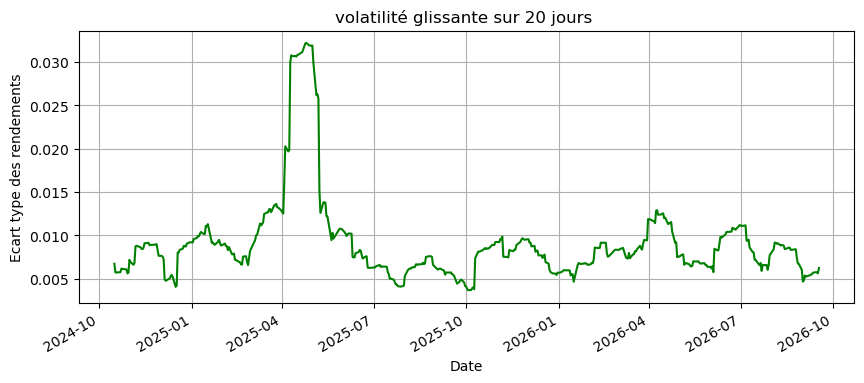

In [19]:
data["volatility_20d"].plot( figsize= (10,4), title= "volatilité glissante sur 20 jours ", color= "green")
plt.xlabel("Date")
plt.ylabel("Ecart type des rendements")
plt.grid(True)
plt.show

### Interprétation

La courbe représente la variation de la dispersion des rendements au fil du temps.

Lorsque la courbe augmente, les rendements des 20 dernières séances sont davantage dispersés. Le marché a alors connu des mouvements plus irréguliers ou plus importants.

Lorsque la courbe diminue, les rendements récents sont plus proches les uns des autres et la période est relativement plus calme.

Cette mesure est utile pour observer l'évolution de la volatilité dans le temps. Toutefois, comme elle n'est pas annualisée, ses valeurs sont moins faciles à comparer avec des indicateurs financiers généralement exprimés en pourcentage annuel.Ainsi,cette volatilité sera exprimée en pourcentage annuel dans la suite.

In [20]:
print(data[["return","volatility_20d"]].tail()) # Curieux de savoir à quoi ressemble les dernières valeurs
print(data["volatility_20d"].dropna().iloc[-1]) # iloc affiche la dernière valeur valeur disponible de la colonne

Price         return  volatility_20d
Date                                
2026-09-11  0.008599        0.005668
2026-09-14 -0.004832        0.005734
2026-09-15 -0.004495        0.005709
2026-09-16 -0.004472        0.005603
2026-09-17  0.011381        0.006215
0.006215381118388542


### Volatilité annualisée  et graphique

Nous convertissons maintenant la volatilité non annualisée en volatilité annualisée .Ce redimentionnement nous permettra d'avoir une volatilité sur une base annuelle et exprimée en pourcentage.

In [21]:
data["volatility_20d_annualized"]= ( data["volatility_20d"] * (252 ** 0.5))

In [22]:
data["volatility_20d_annualized_pct"]= (data["volatility_20d_annualized"] * 100) # volatilité annualisée en pourcentage

In [23]:
print( data[["return","volatility_20d","volatility_20d_annualized_pct"]].tail()) # Afin de voir les nouvelles colones ajoutées et curieusement les derniéres valeurs.

Price         return  volatility_20d  volatility_20d_annualized_pct
Date                                                               
2026-09-11  0.008599        0.005668                       8.998126
2026-09-14 -0.004832        0.005734                       9.103025
2026-09-15 -0.004495        0.005709                       9.062159
2026-09-16 -0.004472        0.005603                       8.894324
2026-09-17  0.011381        0.006215                       9.866612


Ce graphique ci dessous reprend la même volatilité calculée sur une fénêtre de 20 séances , mais annualisée et exprimée en pourcentage. 

<function matplotlib.pyplot.show(close=None, block=None)>

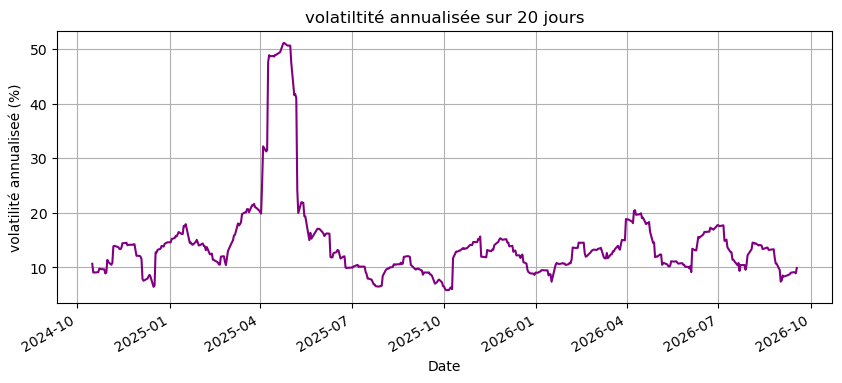

In [24]:
data["volatility_20d_annualized_pct"].plot( figsize=(10,4),title= "volatiltité annualisée sur 20 jours",color= "purple")
plt.xlabel("Date")
plt.ylabel("volatilité annualiseé (%)")
plt.grid(True)
plt.show

### Interprétation

La volatilité annualisée présente une forme générale assez similaire à celle de de la volatilité non annualisée. Cela est naturel car les deux volatilités utilisent les mêmes rendements.

Cette réside uniquement au niveau de l'echelle où la volatilité annualisée est calculé en pourcentage annuel afin de facliter son inteprétation et sa comparaison avec les indicateurs financiers.


### Synthèse
 #### Comparaison des deux mesures

La volatilité non annualisée et la volatilité annualisée sont calculées sur la même fenêtre glissante de 20 séances. La première conserve l'échelle issue des rendements journaliers, tandis que la seconde est convertie sur une base annuelle et exprimée en pourcentage.

L'annualisation ne modifie pas la dynamique de la courbe. Elle modifie seulement l'unité et l'échelle des valeurs. Les deux graphiques présentent donc généralement une forme similaire, mais la volatilité annualisée est plus facile à interpréter dans un contexte financier.

### Comparaison avec la volatilité moyenne

Nous comparons la volatilité annualisée sur une fénêtre de 20 jours à sa moyenne calculée sur toute la période étudiée. 
La moyenne sert de seuil de référence. 
Elle permet de distinguer les périodes où la volatilité est supérieure à son niveau habituel dans l'échantillon, et les périodes où elle inférieure.

#### Illustration 

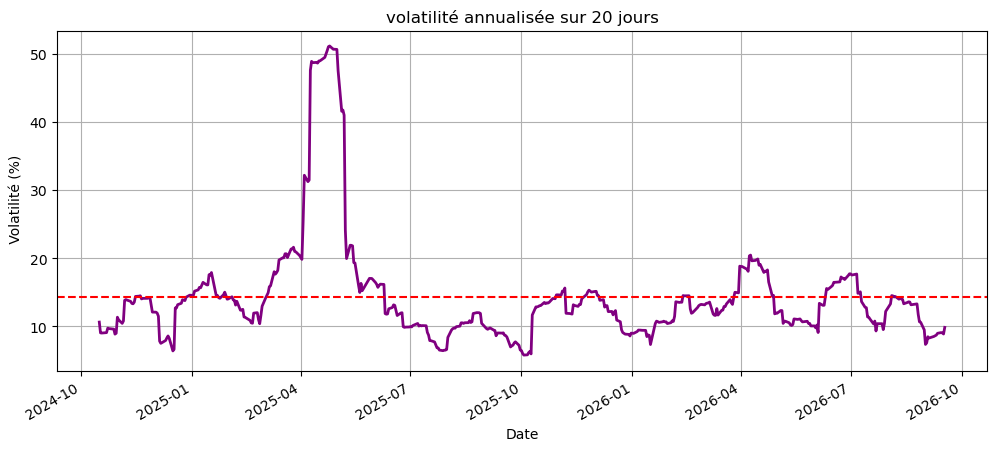

In [25]:
vol = data["volatility_20d_annualized_pct"].dropna()
moyenne= vol.mean()
vol.plot(figsize= (12,5), color= "purple", linewidth= 2)
plt.axhline(moyenne,color= "red",linestyle="--")
plt.title("volatilité annualisée sur 20 jours")
plt.xlabel("Date")
plt.ylabel(" Volatilité (%)")
plt.grid(True)
plt.show()

### Interprétation

La ligne rouge représente la volatilité moyenne calculée sur l'ensemble de la période étudiée.

La courbe violette représente la volatilité calculé sur les 20 dernières séances à chaque date.

Lorsque la courbe violette se situe au dessus de la ligne rouge, la volatilité sur les 20 dernières séances est supérieure à la moyenne de l'échantilon . Cela correspond à une période relativement plus agitée du marché.

Par contre,lorsque la courbe se situe en dessous de la ligne rouge , la volatilité sur les 20 dernières séances est inférieure à la moyenne.Cela correspond à une période plus relativement plus calme.

Notons que la  dernière valeur de la courbe correspond à la volatilité calculée sur les 20 dernières séances disponibles et non le rendement du dernier jour uniquement.


### Résumé statistique de la volatilité 

Après avoir observé l'évolution de la volatilité sur le graphique , nous calculons à présent quatres indicateurs qui permettron de mesurer le dégré de volatilité obsevée durant notre période étudiée:
volatilité minimale,volatilité maximale,volatilité moyenne,volatilité récente.


In [26]:
 vol = data["volatility_20d_annualized_pct"].dropna() # On retire les valeurs manquantes 
print("volatilité minimale:",round(vol.min(),2),"%")
print("volatilité maximale:",round(vol.max(),2),"%")
print("volatilité récente:",round(vol.iloc[-1],2),"%")
print("Volatilité moyenne:",round(vol.mean(),2),"%")

volatilité minimale: 5.81 %
volatilité maximale: 51.12 %
volatilité récente: 9.87 %
Volatilité moyenne: 14.31 %


### Interprétation et synthèse

La volatilité minimale correspond à la période la plus faible observé pendant notre période étudiée.Elle correpond à une période où les rendements des 20 dernières séances etaient relativement très peu dispersés

 La volatilité maximale correspond à la période la forte observée pendant notre pérode étudiée. Elle correspond à une période où les rendements des 20 jours étaient les plus dispersés pour note période et où les mouvements de marché étaient importants .

 La volatilité moyenne sert ici de seuil de reférence pour l'ensemble de la période.

 La volatilité récente ou encore la dernière valeur disponible de la volatilité résume les 20 dernières valeurs de rendements à la fin de l'échantillon ; Ce qui est interressant ,c'est que elle peut étre comparée à la moyenne pour déterminer si la période finale est relativement calme ou agitée: Dans notre cas , on voit très bien que la période est calme car la volatilité moyenne est de 14,32 %  et la volatilité récente est de 9,07 % .

In [27]:
# Les valeurs précédentes montre que la période actuelle du marché est plus calme que la moyenne 
# si la récente était supérieure à la moyenne alors la periode actuelle serait plus agitée que la moyenne
#Si elles sont proches , l'utilisation actuelle est relativement normale
ecart= vol.iloc[-1] - vol.mean()
print(" écart par  rapport à la moyenne:", round(ecart,2),"points de pourcentage")


 écart par  rapport à la moyenne: -4.44 points de pourcentage


## Comparaison avec la volatilité sur 60 jours et graphique

Nous allons maintenant éffectuer une comparaison, disons statégique, de la volatilité sur différentes fénêtres notamment les fénêtres glissantes sur 20 jours et sur 60 jours.

Nous verrons que la volatilité glissante sur 20 jours réagit plus rapidement aux changements récents, autrement dit,le changement sera bien plus visible .Par contre, étant donné que la fénêtre de 60 jours utilise davantage d'observations, on aura généralement un aspect plus progressif de la volatiltité et sera relativement moins visible.

Les deux mesures sont annualisées et exprimées en pourcentage afin d'être sur le même standing d'echelle et d'être comparables.

In [28]:
# Nous allons maintenant créer une variante  sur 60 jours et faire une comparaison

data["volatility_60d"]= (data["return"].rolling(window=60).std())
data["volatility_60d_annualized_pct"]= data["volatility_60d"]*(252**0.5)*100   
print(data[["volatility_20d_annualized_pct","volatility_60d_annualized_pct"]].tail()) # Illustration curieuse


Price       volatility_20d_annualized_pct  volatility_60d_annualized_pct
Date                                                                    
2026-09-11                       8.998126                      11.558616
2026-09-14                       9.103025                      11.315523
2026-09-15                       9.062159                      11.150120
2026-09-16                       8.894324                      11.162721
2026-09-17                       9.866612                      10.973480


<function matplotlib.pyplot.show(close=None, block=None)>

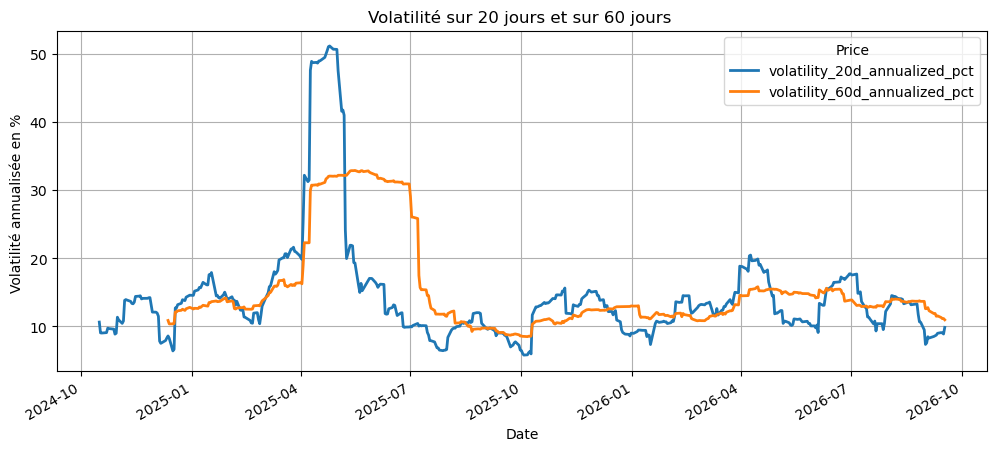

In [29]:
data[["volatility_20d_annualized_pct","volatility_60d_annualized_pct"]].plot(figsize= (12,5),title="Volatilité sur 20 jours et sur 60 jours ", linewidth=2)
plt.xlabel( "Date")
plt.ylabel("Volatilité annualisée en % ")
plt.grid( True)
plt.show

#### Remarque

La fénêtre de 60 jours a besoin de 60 rendements avant de calculer sa première valeur. Les premières lignes peuvent donc contenir la valeur NaN. C'est la raison pour laquelle les deux courbes démarrent tardivement et la courbe de la volatilité sur 60 jours démarre plus tardiment que la courbe de la volatilité sur 20 jours.  

###  Interprétation

La volatilité sur 20 jours réagit plus rapidement aux changements récents que la volatilité sur 60 jours. C'est même d'ailleurs la raison pour laquelle elle présente des pics plus visibles.
La volatilité sur 60 jours par contre réagit de façon plus progressive aux changements car elle prend en compte un grand nombre d'observations, c'est pourquoi on observe une courbe plus lisse.

Lorsque la volatilité sur 20 jours est au dessus de la volatilité sur 60 jours , cela signifie que la volatilité récente ou encore les mouvements récents sont plus importants que la tendance sur une longue période.
En revanche, si la courbe passe en dessous de la courbe , cela signifie que les mouvements récents sont devenues relativement plus calmes que ceux observés sur les 60 dernières séances

Certes,nous deux courbes mesurent la volatilité annualisée, mais elles ne répondent pas à la même question: Les 20 jours décrivent le court terme tandis que les 60 jours décrivent une période plus progressive.


## Corrélation et examen de l'évolution entre les rendements et la volatilité

### Relation entre les rendements et la volatilité

Nous allons étudier la relation entre les rendements journaliers et la volatilité annualisée sur 20 jours.

Deux analyses sont réalisées avec le même nuage de points. Dans la première, nous conservons le signe du rendement afin d'étudier le lien avec la direction du mouvement. Dans la seconde, nous utilisons la valeur absolue du rendement afin d'étudier le lien avec l'amplitude du mouvement, qu'il soit positif ou négatif.

La volatilité utilisée sur l'axe vertical est la volatilité annualisée sur 20 jours.

In [30]:
# Analyse avec le rendement signé
analyse_signe = data[[ "return","volatility_20d_annualized_pct" ]].dropna()

correlation_signe = analyse_signe["return"].corr(analyse_signe["volatility_20d_annualized_pct"])

# Analyse avec l'amplitude absolue du rendement
data["abs_return"] = data["return"].abs()

analyse_abs = data[[ "abs_return","volatility_20d_annualized_pct"]].dropna()

correlation_abs = analyse_abs["abs_return"].corr(analyse_abs["volatility_20d_annualized_pct"])

print("Corrélation avec le rendement signé :",round(correlation_signe, 3))

print("Corrélation avec l'amplitude absolue :", round(correlation_abs, 3))

Corrélation avec le rendement signé : 0.082
Corrélation avec l'amplitude absolue : 0.356


Illustration

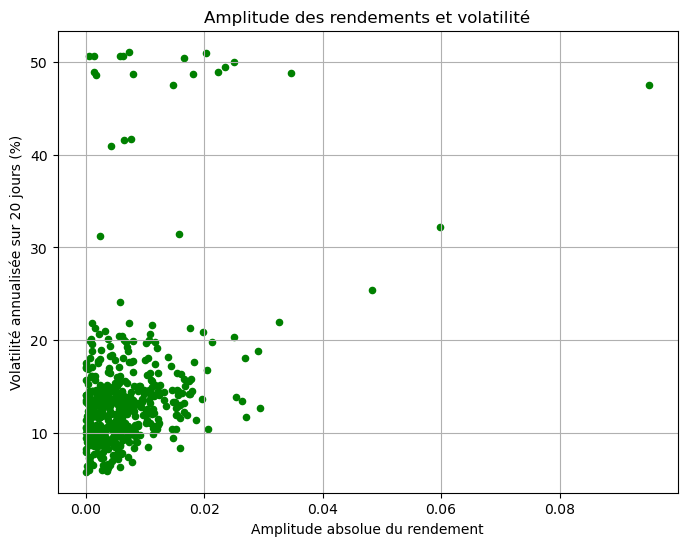

In [31]:
analyse_abs.plot(
    x="abs_return",
    
   y="volatility_20d_annualized_pct",
    
    kind="scatter",
    
    figsize=(8, 6),

    color= "green",
    
    title="Amplitude des rendements et volatilité"
  )

plt.xlabel("Amplitude absolue du rendement")
plt.ylabel("Volatilité annualisée sur 20 jours (%)")
plt.grid(True)
plt.show()

### Interprétation du nuage de points

Le nuage de points est dispersé et ne présente pas de tendance linéaire très nette.

La corrélation entre le rendement signé et la volatilité est de 0,08. Cette valeur très proche de zéro indique que la direction d'un rendement journalier explique très peu la volatilité récente.

Lorsque le rendement est remplacé par sa valeur absolue, la corrélation augmente à 0,357. Cette relation positive faible à modérée suggère que les mouvements journaliers de grande amplitude sont plus souvent associés à une volatilité élevée.

La différence entre les deux corrélations montre que la volatilité est davantage liée à l'importance des mouvements qu'à leur direction. Cependant, la dispersion du nuage indique que cette relation reste imparaite.

ique.

La dispersion des points montre que l'amplitude d'un seul rendement ne suffit pas à expliquer toute la volatilité calculée sur une fenêtre de 20 jours.

## Regime de préférence

### Classification des régimes de volatilité sur 20 jours

Nous classons chaque date selon le niveau de volatilité annualisée sur 20 jours.

Une date est classée dans le régime **élevée** lorsque sa volatilité est superieure ou égale à la moyenne de la période (seuil) . Elle est classée dans le régime **faible** lorsque la volatilité est inférieure ou égale à la moyenne de la période.
Cette classification permet de repérer plus facilement les périodes relativement plus calmes et les périodes relativement plus agitées.


In [32]:
seuil= vol.mean()

data["regime volatilite"] = "faible" #là je crèe une nouvelle colonne où toutes les ligne recoivent faible
# on considère toutes les dates comme des périodes de volatilité faible

data.loc[ data["volatility_20d_annualized_pct"]> seuil,"regime volatilite"] = "elevée" # elle signifie simplement si la volatlité d'une dat est supérieure à la moyenne , ecris élevé dans la nouvelle colonne regime volatilite
print(data[["volatility_20d_annualized_pct","regime volatilite"]].tail())

Price       volatility_20d_annualized_pct regime volatilite
Date                                                       
2026-09-11                       8.998126            faible
2026-09-14                       9.103025            faible
2026-09-15                       9.062159            faible
2026-09-16                       8.894324            faible
2026-09-17                       9.866612            faible


#### Remarque
Les dernières valeurs affiché sont au régime faible car les dernières valeurs sont inférieures au seuil moyen. 


In [33]:
print(data["regime volatilite"].value_counts())

regime volatilite
faible    349
elevée    152
Name: count, dtype: int64


#### Remarque 
Il faut faire attention au calcul du nombre d'occurences du régime **faible**. En effet les valeurs manquantes ou indisponibles de notre serie de la volatilité annualisée sur 20 jours ont été consideré par défaut inférieur au seuil et prennent automatiquement la chaine de caractère "faible". On règle ce problème avec la solution 
ci-dessous:

In [34]:
import pandas as pd
data["regime volatilite"] = data["volatility_20d_annualized_pct"].apply (lambda x : "élevée" if x > seuil else( "faible" if pd.notna(x) else "indisponible"))

In [35]:
print(data["regime volatilite"].value_counts())  # Ceci permettra de regler le cas des valeurs NAN CAR par défaut sans ça "NAN> SEUIL" IMPLIQUE la valeur 'faible'

regime volatilite
faible          329
élevée          152
indisponible     20
Name: count, dtype: int64


#### Remarque 
On constate maintenant que le nombre d'occurences du régime **faible** à diminué. Ceci confirme bien évidemment notre hypothèse passée.

### Maximun et minimun

Nous recherchons maintenant les dates auxquelles la volatilité annualisée sur 20 jours a atteint sa valeur maximale ou sa valeur minimale.


In [36]:
date_max = data["volatility_20d_annualized_pct"].idxmax()
valeur_max = data["volatility_20d_annualized_pct"].max()
print("Date du maximun:",date_max)
print("volatilité maximale:",round(valeur_max,2),"%")

Date du maximun: 2025-04-25 00:00:00
volatilité maximale: 51.12 %


In [37]:
print(data.loc[date_max])# selectionne toute la ligne à partir de l'étiquette relié à date_max
  # Curieux de voir tous les infos précises de cette date...

Price
Close                            5525.209961
High                             5528.109863
Low                              5455.859863
Open                              5489.72998
Volume                            4236580000
return                              0.007373
volatility_20d                      0.032201
volatility_20d_annualized           0.511177
volatility_20d_annualized_pct      51.117717
volatility_60d                      0.020189
volatility_60d_annualized_pct      32.049483
abs_return                          0.007373
regime volatilite                     élevée
Name: 2025-04-25 00:00:00, dtype: object


In [38]:
date_min = vol.idxmin()
valeur_min = vol.min()

print("Date du minimun:",date_min)
print("volatilité minimale:",round(valeur_min,2),"%")

Date du minimun: 2025-10-03 00:00:00
volatilité minimale: 5.81 %


#### Interprétation

La volatilité annualisée maximale est de 51,12 % le 25 avril 2025. Cette date correspond à la période la plus agitée de notre échantillon.

La volatilité minimale observée est de 5,81 %  le 3 octobre 2025.Cette date correspond à la période la plus calme de l'échantillon.

Ces valeurs ne correspondent en aucun cas une perte ou un gain du marché mais plutot des mesures de l'intensité fluctuations des rendements sur une fénêtre glissante de 20 jours exprimées en base annuelle.


#### Volatilité moyenne par régime

Cette étape consiste à vérifier le niveau de volatilité des régimes **faible** et **élévée**. Le groupe **indisponible** n'a pas de volatilité calculable car elle correspond justement aux premières dates où la fénêtre de 20 jours n'était pas encore complète.

In [39]:
# La question suivante qu'on se pose:  EST CE QUE LES RENDEMENTS MOYENS SONT DIFFERENTS PENDANT LES PÉRIODES DE VARIATION FAIBLE ET ÉLEVÉES?

moyennes_regimes=data.groupby( "regime volatilite")["return"].mean()  # Là on essaie de calculer les moyennes pour chacun des groupes notamment les groupes faibles, élevée, et indisponible qui ne nous servira évidemment pas...
print("Rendements moyens par regime(%):")
print(moyennes_regimes*100)

Rendements moyens par regime(%):
regime volatilite
faible          0.032205
indisponible    0.183773
élevée          0.126244
Name: return, dtype: float64


#### Interprétation
 
La volatilité moyenne du régime élevée est supérieure à celle du régime faible, ce qui cohérent et normal d'après notre règle de classification.

Le régime faible regroupe ici les dates où la volatilité est inférieur à la moyenne, alors que le régime élevée regroupe ceux dont la volatilité est supérieur à la volatilité moyenne.


### Tableau récapitulatif
Le tableau suivant rassemble les principaux indicateurs calculés pendant l'analyse.

In [40]:
resume = pd.DataFrame({ "indicateur": ["volatilité minimale (%)","volatilité maximale(%)","volatilité récente(%)","volatilité moyenne(%)","Corrélation amplitude-volatilité"],"valeur": [ round(vol.min(),2),round(vol.max(),2),round(vol.iloc[-1],2),round(vol.mean(),2),round(correlation_abs,3)] })
print(resume)

                         indicateur  valeur
0           volatilité minimale (%)   5.810
1            volatilité maximale(%)  51.120
2             volatilité récente(%)   9.870
3             volatilité moyenne(%)  14.310
4  Corrélation amplitude-volatilité   0.356


La volatilité maximale est nettement supérieure à la volatilité minimale, ce qui montre que le niveau d'agitation du marché a fortement variée pendant notre période étudiée.

In [41]:
print(data.columns) # Juste curieux de voir mon tableau de fin

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'return', 'volatility_20d',
       'volatility_20d_annualized', 'volatility_20d_annualized_pct',
       'volatility_60d', 'volatility_60d_annualized_pct', 'abs_return',
       'regime volatilite'],
      dtype='object', name='Price')


## Résultats principaux

-La volatilité minimale observée est de 5,81 % , le 3 octobre 2025.
-La volatilité maximale observée est de 51,12 % , le 25 avril 2025.
- La volatilité récente est proche de 9 %.
- La corrélation entre l'amplitude absolue de rendements et la volatilité est de 0,357.
- La période étudiée contient 329 observations classées en régime de  volatilité faible et 151 observations classées en régime de volatlité élevée.
- Enfin 20 observations sont indisponibles au début de la série, car la fénêtre de 20 jours n'est pas encore complet.

## Conclusion

Cette étude a permis d'analyser la volatilité d'un indice financier à partir de ses prix historiques.

Les rendements journaliers ont été calculés à partir de prix de clôture, puis une volatilité glissante sur 20 jours à été estimée et annualisée. Ensuite une comparaison avec une fénêtre de 60 jours a permis de distinguer les variations rapides des tendances plus générales.

La volatilité maximale observée est de 51,12 % le 25 avril 2025, tandis que que la volatilité minimale est de 5,81 % le 3 octobre 2025. La volatlité récente, proche de 9 % , est nettement inférieure au maximun observée.

Enfin , la corrélation de 0,357 entre l'amplitude absolue des rendements et la volatilité indique une relation positive faible à modérée.

Ces résultats décrivent uniquement la période étudiée , mais ne permettent de decrire avec certitude les mouvements futurs du marché.

Après les calculs et les interprétations nous enregistrons à présent le tableau final dans un fichier **CSV** afin de converser les données pour les utiliser ultérieurement.Ce fichier contient les prix, les rendements, les volatilités sur 20 et 60 jours , les versions annualisées et la classification de nos régimes de volatilité.

In [46]:
data.to_csv( "analyse volatilite_finale.csv",index=True)

In [47]:
import os
print(os.path.exists("analyse volatilite_finale.csv"))

True
